# Test PP(XW) for draws from a Cauchy distribution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

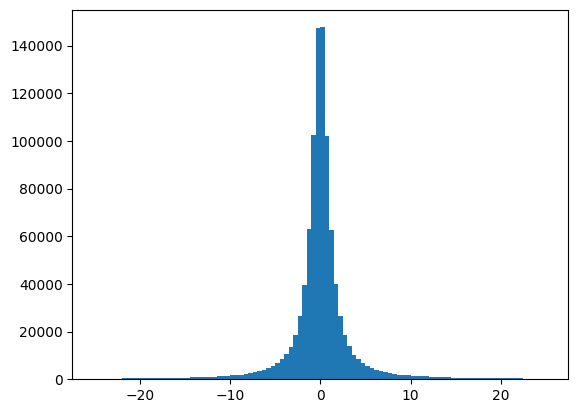

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Draw 1,000,000 samples from a standard Cauchy distribution
samples = np.random.standard_cauchy(1000000)

# Truncate the distribution for better plotting
samples = samples[(samples > -25) & (samples < 25)]

# Plot the histogram of the samples
plt.hist(samples, bins=100)
plt.show()

In [ ]:
d = 10
samples = np.random.standard_cauchy(d)
print(samples)

In [9]:
N = 1000
d = 500
alpha = 2.0

X = pp.generate_data_manifold(N, d, alpha)
print(X.shape)

Wc = pp.generate_square_weight_matrix(d = d,
                                  alpha = alpha,
                                  uniform_draws = False,
                                  use_pareto = False,
                                  use_uniform = False,
                                  use_cauchy = True,
                                  verbose = True)

print(Wc.shape)
#k = 5
#print(Wc[0:k,0:k])

pp_dim_X = pp.calculate_PatnaikPearson_dim(X)
dim_X = X.shape[1]
nu_over_d_X = pp_dim_X / dim_X
print("pp_dim_X = ", pp_dim_X)
pp_dim_Wc = pp.calculate_PatnaikPearson_dim(Wc)
dim_Wc = Wc.shape[1]
nu_over_d_Wc = pp_dim_Wc / dim_Wc
print("pp_dim_Wc = ", pp_dim_Wc)

XWc = X @ Wc
pp_dim_XWc = pp.calculate_PatnaikPearson_dim(XWc)
dim_XWc = XWc.shape[1]
nu_over_d_XWc = pp_dim_XWc / dim_XWc
print("pp_dim_XWc = ", pp_dim_XWc)

print("nu_over_d_XWc = ", nu_over_d_XWc)
print("min(nu_over_d_X, nu_over_d_Wc) = ", min(nu_over_d_X, nu_over_d_Wc))
print("nu_over_d_X * nu_over_d_Wc = ", nu_over_d_X * nu_over_d_Wc)


(1000, 500)
using cauchy
these_sigmas[0:5] =  [-0.34426384 -0.09035386  0.42723321  0.1366139  -0.13822592]
 ** generate_square_weight_matrix: using GPU **
(500, 500)
pp_dim_X =  285.40819090923526
pp_dim_Wc =  14.946190948047867
pp_dim_XWc =  10.933570346016978
nu_over_d_XWc =  0.021867140692033958
min(nu_over_d_X, nu_over_d_Wc) =  0.029892381896095735
nu_over_d_X * nu_over_d_Wc =  0.01706306127786532
